# Gradient Boosting: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind gradient boosting (gradient descent in function space, pseudo-residuals, shrinkage)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
import ast

MODEL_NAME = "Gradient Boosting"
MODEL_SLUG = "gradient_boosting"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind Gradient Boosting

### 2.1 The Core Idea

Gradient boosting is a **stagewise additive model** where we iteratively fit regression trees to predict pseudo-residuals of the loss function. Unlike AdaBoost which reweights samples, gradient boosting fits trees to the negative gradient of the loss.

The key insight: at each stage, we ask "What are the current errors (gradients)? Fit a tree to predict those errors. Add this tree's predictions (multiplied by a learning rate) to improve the ensemble."

### 2.2 Gradient Descent in Function Space

Traditional gradient descent optimizes weights: $\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$

Gradient boosting optimizes **functions**: $F_{t}(x) = F_{t-1}(x) - \eta h_t(x)$

where:
- $F_t(x)$ is our ensemble prediction at stage $t$
- $\eta$ is the **learning rate** (shrinkage parameter)
- $h_t(x)$ is a regression tree that predicts the negative gradient of the loss at stage $t$
- The negative gradient points in the direction that decreases the loss

### 2.3 Binary Classification with Deviance Loss

For binary classification, we use **deviance loss** (also called log loss or cross-entropy):

$$L(y, F) = -[y \log(p) + (1-y) \log(1-p)]$$

where $p = \sigma(F) = \frac{1}{1 + e^{-F}}$ is the probability from logistic sigmoid.

The negative gradient (pseudo-residual) is:

$$r_i = -\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} = y_i - p_i$$

**Interpretation:** The pseudo-residual is simply the difference between the true class and the current predicted probability. If we predict $p=0.3$ but $y=1$, the residual is $0.7$ (we underestimated). This residual tells the next tree what to correct.

### 2.4 The Gradient Boosting Algorithm

**Initialize:** $F_0(x) = \log\left(\frac{p}{1-p}\right)$ where $p = \frac{\sum y_i}{n}$ (log odds of base rate)

**For each iteration $t = 1, \ldots, T$:**

1. **Compute pseudo-residuals** for each training sample:
   $$r_{i,t} = y_i - p_{i,t-1}$$
   where $p_{i,t-1} = \sigma(F_{t-1}(x_i))$

2. **Fit a regression tree** $h_t(x)$ to predict these residuals using least squares

3. **Compute the optimal step size** (in practice, sklearn uses a fixed learning rate)

4. **Update the ensemble:**
   $$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

   where $\eta$ is the learning rate (e.g., 0.1)

**Final prediction:** 
$$\hat{p}(x) = \sigma(F_T(x)) = \frac{1}{1 + e^{-F_T(x)}}$$

### 2.5 Why Tree Depth Matters

Unlike AdaBoost which uses stumps, gradient boosting typically uses shallow trees with $\text{max\_depth} = 3$ to $5$:

- **Shallow trees** (depth 3): More bias, lower variance, less prone to overfit
- **Deeper trees** (depth 7+): Lower bias, higher variance, captures more interactions
- **Very deep trees** (depth > 10): Risk of overfitting, especially with large learning rates

The combination of shallow trees + many iterations + small learning rate is what makes gradient boosting powerful.

### 2.6 Learning Rate and Shrinkage

The learning rate $\eta$ (between 0 and 1) controls how much each tree contributes:

$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

- **Small learning rate** (0.01 to 0.1): Requires more iterations but better generalization (smaller steps toward the optimum)
- **Large learning rate** (0.5 to 1.0): Fewer iterations but risk of overshooting and overfitting

This is **regularization through shrinkage**. A common practice: reduce learning rate by half and double n_estimators.

### 2.7 Subsampling for Stochasticity

The `subsample` parameter (e.g., 0.8) trains each tree on a random 80% of the data:

- Reduces variance (similar to bagging)
- Adds stochasticity to the boosting process
- Often improves generalization
- Common values: 0.7 to 1.0

### 2.8 Feature Importance from Gradient Boosting

Feature importance is computed as the total reduction in loss contributed by splits on each feature:

$$\text{Importance}(x_j) = \sum_{t=1}^{T} \sum_{\text{nodes where } x_j \text{ is split}} \text{loss reduction}$$

This is sometimes called **gain importance** and differs from MDI in that it measures actual predictive power improvement.

---
## 3. Visualizing Gradient Descent and Loss Reduction

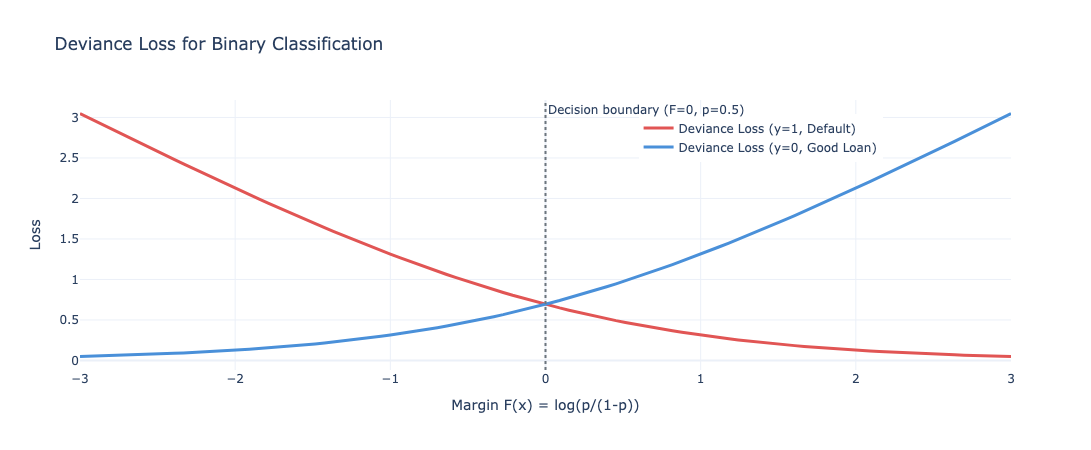

  Saved: outputs/gradient_boosting/deviance_loss.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/gradient_boosting/deviance_loss.html')

In [2]:
# Visualize how deviance loss compares to other losses
# and how gradient descent in function space reduces loss over iterations

margin = np.linspace(-3, 3, 100)
p = 1 / (1 + np.exp(-margin))  # Convert to probability via sigmoid

# For y=1 (default)
deviance_loss_default = -np.log(p)
# For y=0 (good loan)
deviance_loss_good = -np.log(1 - p)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=margin, y=deviance_loss_default, name="Deviance Loss (y=1, Default)",
    line=dict(color=COLORS["red"], width=3),
))
fig.add_trace(go.Scatter(
    x=margin, y=deviance_loss_good, name="Deviance Loss (y=0, Good Loan)",
    line=dict(color=COLORS["accent"], width=3),
))
fig.add_vline(x=0, line_dash="dot", line_color=COLORS["gray"],
              annotation_text="Decision boundary (F=0, p=0.5)")
fig.update_layout(
    title="Deviance Loss for Binary Classification",
    xaxis_title="Margin F(x) = log(p/(1-p))",
    yaxis_title="Loss",
    height=450, width=700,
    legend=dict(x=0.6, y=0.95),
)
fig.show()
save_chart(fig, MODEL_SLUG, "deviance_loss")

---
## 4. Worked Example: Manual Pseudo-Residual Computation

In [3]:
# Demonstrate pseudo-residual computation
examples = get_example_rows(df, n=3)
for idx, row in examples.iterrows():
    print_example_row(row, idx)

print("\n" + "="*70)
print("WORKED EXAMPLE: Pseudo-Residual Computation in Gradient Boosting")
print("="*70)

# Start with initial prediction (log odds of base rate)
base_rate = y_train.mean()
F_0 = np.log(base_rate / (1 - base_rate))
p_0 = 1 / (1 + np.exp(-F_0))

print(f"\nInitial Setup:")
print(f"  Base default rate: {base_rate:.4f}")
print(f"  Initial log odds: F_0 = log({base_rate:.4f} / {1-base_rate:.4f}) = {F_0:.4f}")
print(f"  Initial probability: p_0 = sigmoid({F_0:.4f}) = {p_0:.4f}")

# Select 3 sample borrowers for demo
sample_indices = [0, len(y_train)//4, len(y_train)//2]
sample_indices = [i for i in sample_indices if i < len(y_train)]

print(f"\n--- Pseudo-Residual Computation (Iteration 1) ---")
for idx in sample_indices[:3]:
    y_true = int(y_train.iloc[idx])
    residual = y_true - p_0
    
    print(f"\n  Borrower {idx + 1}:")
    print(f"    True label: y = {y_true} ({'Default' if y_true == 1 else 'Good'})")
    print(f"    Current prediction: p = {p_0:.4f}")
    print(f"    Pseudo-residual: r = y - p = {y_true} - {p_0:.4f} = {residual:.4f}")
    print(f"    Interpretation: This value is what we want the next tree to predict.")

print(f"\n" + "="*70)
print(f"The next decision tree will be trained via regression to predict these")
print(f"pseudo-residuals. The tree learns where the current ensemble is wrong.")
print(f"Once trained, the tree's predictions are added to F_0 with shrinkage:")
print(f"  F_1(x) = F_0 + learning_rate * h_1(x)")


--- Example Borrower 1 (Actual: GOOD) ---
  LOAN           : 10600
  MORTDUE        : 82365.0
  VALUE          : 100272.0
  REASON         : DebtCon
  JOB            : ProfExe
  YOJ            : 3.0
  DEROG          : 1.0
  DELINQ         : 0.0
  CLAGE          : 122.48359427
  NINQ           : 0.0
  CLNO           : 26.0
  DEBTINC        : 33.651646949

--- Example Borrower 2 (Actual: GOOD) ---
  LOAN           : 24800
  MORTDUE        : 82670.0
  VALUE          : 106563.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 8.0
  DEROG          : 0.0
  DELINQ         : 0.0
  CLAGE          : 302.98443202
  NINQ           : 2.0
  CLNO           : 28.0
  DEBTINC        : 30.956485836

--- Example Borrower 3 (Actual: DEFAULT) ---
  LOAN           : 9900
  MORTDUE        : 71371.0
  VALUE          : 84865.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 0.0
  DEROG          : 2.0
  DELINQ         : 0.0
  CLAGE          : 94.805235749
  NINQ         

---
## 5. Model Training with Hyperparameter Tuning

In [4]:
# Hyperparameter grid for Gradient Boosting
param_grid = {
    "clf__n_estimators": [50, 100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [3, 5, 7],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__subsample": [0.8, 1.0],
}

gb_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", GradientBoostingClassifier(
        loss="log_loss",  # Deviance loss for binary classification
        random_state=RANDOM_STATE,
        init="zero",
    )),
])

grid = GridSearchCV(
    gb_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

best_gb = grid.best_estimator_
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

gb_clf = best_gb.named_steps["clf"]
print(f"\nBest model:")
print(f"  N estimators: {gb_clf.n_estimators}")
print(f"  Learning rate: {gb_clf.learning_rate}")
print(f"  Max depth: {gb_clf.max_depth}")
print(f"  Subsample: {gb_clf.subsample}")
print(f"  Min samples leaf: {gb_clf.min_samples_leaf}")

Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Best CV recall: 0.7411

Best model:
  N estimators: 300
  Learning rate: 0.1
  Max depth: 7
  Subsample: 0.8
  Min samples leaf: 20


---
## 6. Model Evaluation

In [5]:
# Cross-validation score
cv_scores = cross_val_score(best_gb, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_gb, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.73595506 0.74157303 0.78651685 0.73184358 0.70949721]
CV Recall mean: 0.7411 (+/- 0.0252)

  Gradient Boosting
  Recall: 0.6902  |  Precision: 0.8913  |  F1: 0.7780
  AUC: 0.9682  |  PR-AUC: 0.9088
  Confusion: TP=205 FP=25 FN=92 TN=1168

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.93      0.98      0.95      1193
     Default       0.89      0.69      0.78       297

    accuracy                           0.92      1490
   macro avg       0.91      0.83      0.87      1490
weighted avg       0.92      0.92      0.92      1490



---
## 7. Staged Predictions: Performance vs Number of Estimators

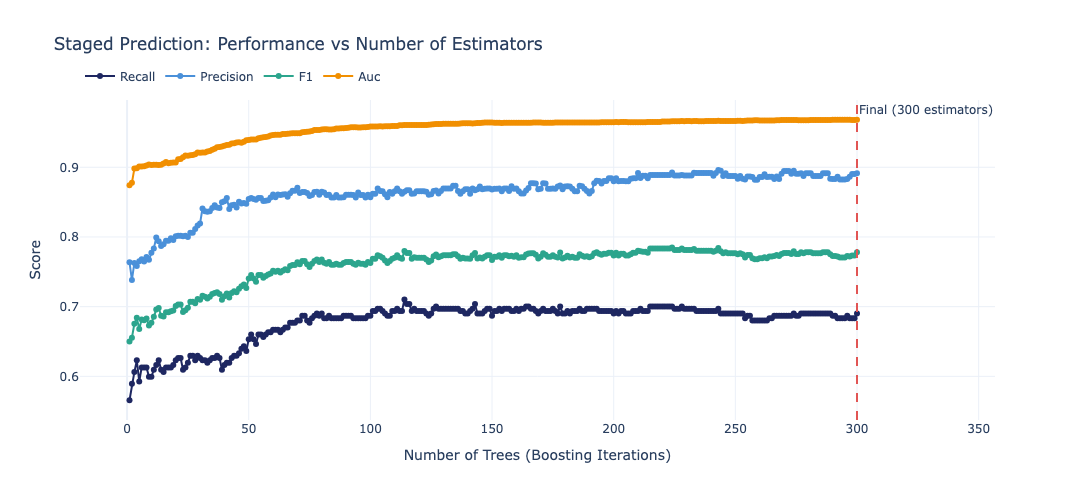

  Saved: outputs/gradient_boosting/staged_predictions.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/gradient_boosting/staged_predictions.html')

In [7]:
# Transform X_test through the preprocessing pipeline
preprocessor = best_gb.named_steps["prep"]
X_test_prep = preprocessor.transform(X_test)
gb_clf = best_gb.named_steps["clf"]

# Use staged_predict_proba to see performance at each boosting iteration
n_stages = len(gb_clf.estimators_)
staged_results = []
staged_proba_gen = gb_clf.staged_predict_proba(X_test_prep)
for i, y_pred_stage in enumerate(gb_clf.staged_predict(X_test_prep), 1):
    y_score_stage = next(staged_proba_gen)[:, 1]

    recall = recall_score(y_test, y_pred_stage)
    precision = precision_score(y_test, y_pred_stage, zero_division=0)
    f1 = f1_score(y_test, y_pred_stage)
    auc = roc_auc_score(y_test, y_score_stage)

    staged_results.append({
        "n_estimators": i,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "auc": auc,
    })

df_staged = pd.DataFrame(staged_results)
fig_staged = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"]), ("auc", COLORS["orange"])]:
    fig_staged.add_trace(go.Scatter(
        x=df_staged["n_estimators"], y=df_staged[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))
fig_staged.add_vline(x=gb_clf.n_estimators, line_dash="dash", line_color=COLORS["red"],
                      annotation_text=f"Final ({gb_clf.n_estimators} estimators)")
fig_staged.update_layout(
    title="Staged Prediction: Performance vs Number of Estimators",
    xaxis_title="Number of Trees (Boosting Iterations)",
    yaxis_title="Score",
    height=500, width=750,
    legend=dict(orientation="h", y=1.12),
)
fig_staged.show()
save_chart(fig_staged, MODEL_SLUG, "staged_predictions")

---
## 8. Learning Rate Sensitivity

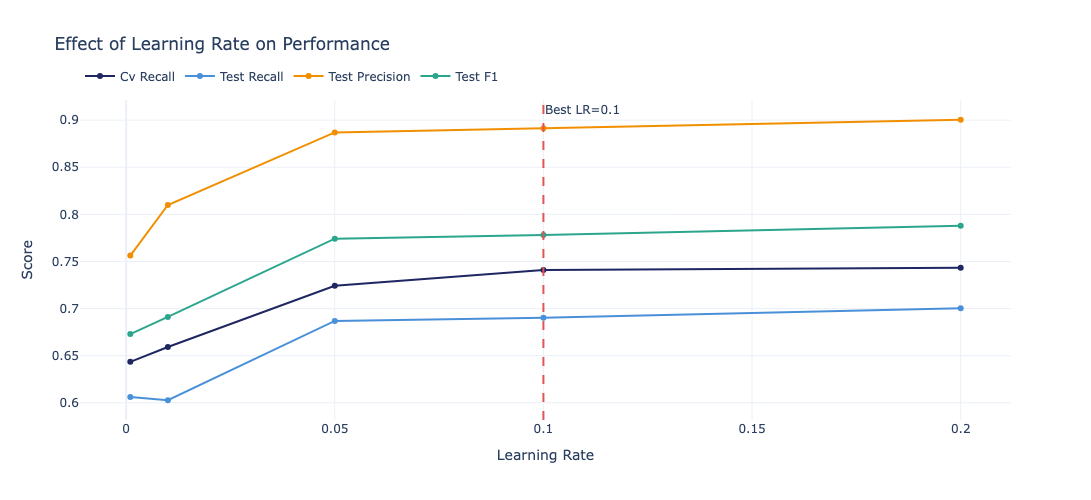

  Saved: outputs/gradient_boosting/learning_rate_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/gradient_boosting/learning_rate_sensitivity.html')

In [8]:
# Sweep learning rate with fixed other parameters
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]
lr_results = []

best_n_est = best_gb.named_steps["clf"].n_estimators
best_max_depth = best_gb.named_steps["clf"].max_depth
best_min_samples_leaf = best_gb.named_steps["clf"].min_samples_leaf
best_subsample = best_gb.named_steps["clf"].subsample

for lr in learning_rates:
    gb_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", GradientBoostingClassifier(
            loss="log_loss",
            n_estimators=best_n_est,
            learning_rate=lr,
            max_depth=best_max_depth,
            min_samples_leaf=best_min_samples_leaf,
            subsample=best_subsample,
            random_state=RANDOM_STATE,
            init="zero",
        )),
    ])
    
    # CV score
    cv_sc = cross_val_score(gb_temp, X_train, y_train, cv=cv, scoring="recall").mean()
    
    # Train and test
    gb_temp.fit(X_train, y_train)
    y_pred_t = gb_temp.predict(X_test)
    y_prob_t = gb_temp.predict_proba(X_test)[:, 1]
    
    lr_results.append({
        "learning_rate": lr,
        "cv_recall": cv_sc,
        "test_recall": recall_score(y_test, y_pred_t),
        "test_precision": precision_score(y_test, y_pred_t, zero_division=0),
        "test_f1": f1_score(y_test, y_pred_t),
        "test_auc": roc_auc_score(y_test, y_prob_t),
    })

df_lr = pd.DataFrame(lr_results)

fig_lr = go.Figure()
for metric, color in [("cv_recall", COLORS["navy"]), ("test_recall", COLORS["accent"]),
                       ("test_precision", COLORS["orange"]), ("test_f1", COLORS["green"])]:
    fig_lr.add_trace(go.Scatter(
        x=df_lr["learning_rate"], y=df_lr[metric],
        name=metric.replace("_", " ").title(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))

fig_lr.add_vline(x=best_gb.named_steps["clf"].learning_rate, line_dash="dash", line_color=COLORS["red"],
                  annotation_text=f"Best LR={best_gb.named_steps['clf'].learning_rate}")

fig_lr.update_layout(
    title="Effect of Learning Rate on Performance",
    xaxis_title="Learning Rate",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_lr.show()
save_chart(fig_lr, MODEL_SLUG, "learning_rate_sensitivity")

---
## 9. Feature Importance (Gain-based)

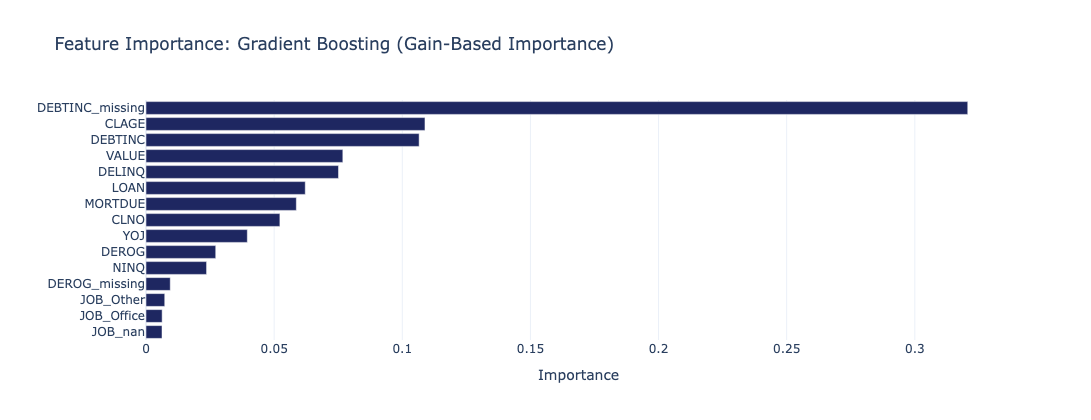

  Saved: outputs/gradient_boosting/feature_importance.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/gradient_boosting/feature_importance.html')

In [9]:
# Get feature names after preprocessing
preprocessor = best_gb.named_steps["prep"]
cat_encoder = preprocessor.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Feature importance (gain-based from Gradient Boosting)
importances = gb_clf.feature_importances_

fig_imp = plot_feature_importance(importances, all_feature_names, MODEL_NAME, "Gain-Based Importance")
fig_imp.show()
save_chart(fig_imp, MODEL_SLUG, "feature_importance")

---
## 10. Partial Dependence Plots (Top 3 Features)

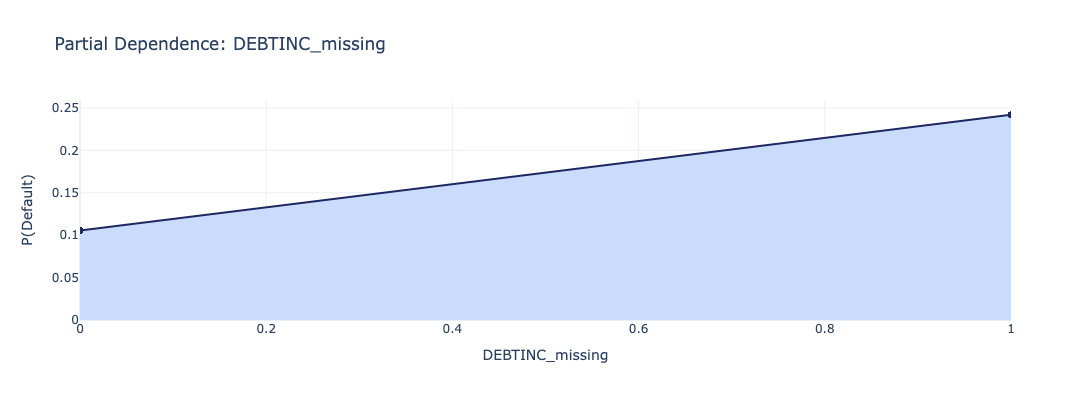

  Saved: outputs/gradient_boosting/partial_dependence_1.html


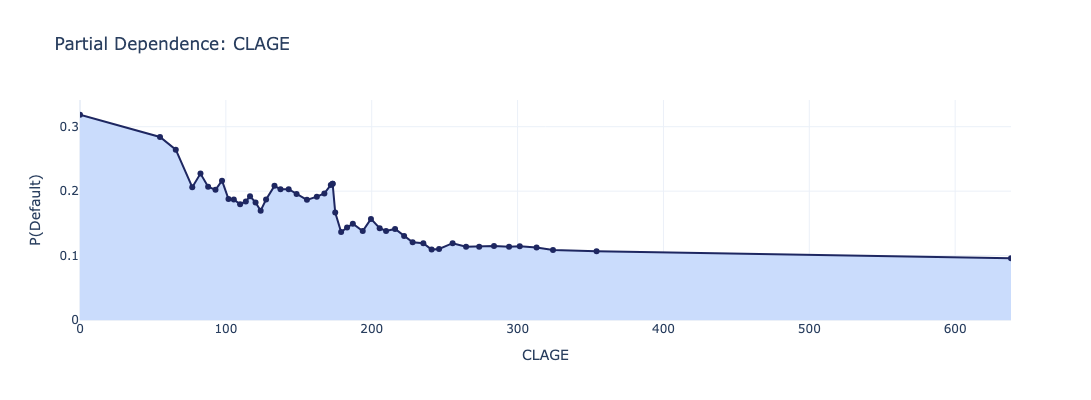

  Saved: outputs/gradient_boosting/partial_dependence_2.html


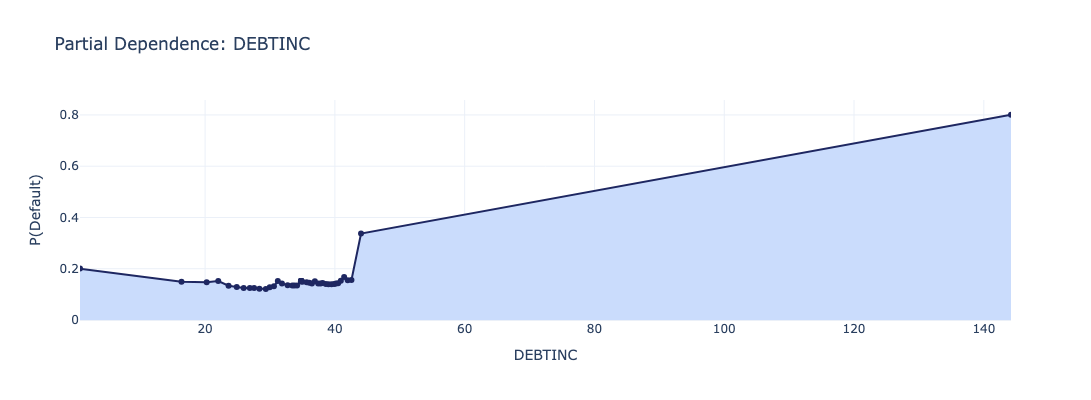

  Saved: outputs/gradient_boosting/partial_dependence_3.html


In [10]:
# Get indices of top 3 features by importance
top_3_indices = np.argsort(importances)[-3:][::-1]
top_3_names = [all_feature_names[i] for i in top_3_indices]
top_3_original_indices = [i for i in top_3_indices]

# Transform test data for plotting
X_test_transformed = best_gb.named_steps["prep"].transform(X_test)

# Create partial dependence plots
for feat_idx, feat_name in zip(top_3_original_indices, top_3_names):
    # Compute partial dependence manually for plotly visualization
    feature_vals = np.percentile(X_test_transformed[:, feat_idx], np.linspace(0, 100, 50))
    pd_values = []
    
    X_test_copy = X_test_transformed.copy()
    for val in feature_vals:
        X_test_copy[:, feat_idx] = val
        y_pred_proba = best_gb.named_steps["clf"].predict_proba(X_test_copy)[:, 1]
        pd_values.append(y_pred_proba.mean())
    
    fig_pd = go.Figure()
    fig_pd.add_trace(go.Scatter(
        x=feature_vals, y=pd_values,
        mode="lines+markers",
        name=feat_name,
        line=dict(color=COLORS["navy"], width=2),
        fill="tozeroy",
        fillcolor=COLORS["ice"],
    ))
    
    fig_pd.update_layout(
        title=f"Partial Dependence: {feat_name}",
        xaxis_title=feat_name,
        yaxis_title="P(Default)",
        height=400, width=600,
    )
    fig_pd.show()
    save_chart(fig_pd, MODEL_SLUG, f"partial_dependence_{top_3_names.index(feat_name) + 1}")

---
## 11. Decision Boundary (2D PCA Projection)

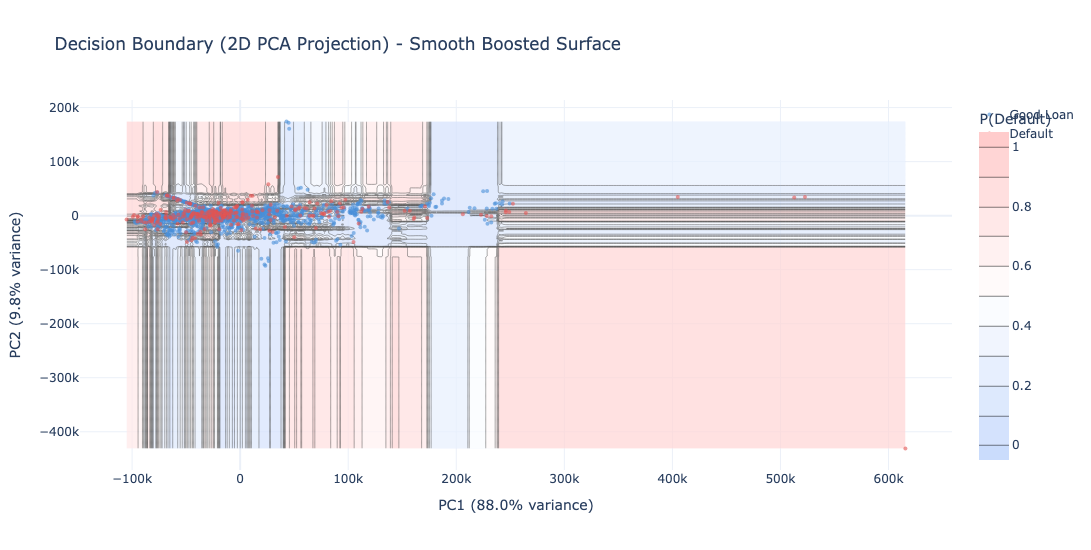

  Saved: outputs/gradient_boosting/decision_boundary_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/gradient_boosting/decision_boundary_2d.html')

In [12]:
from sklearn.decomposition import PCA

# Transform and reduce to 2D
X_train_transformed = prep_tree.fit_transform(X_train)
X_test_transformed = prep_tree.transform(X_test)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_transformed)
X_test_2d = pca.transform(X_test_transformed)

# Train GB on 2D
gb_2d = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=best_gb.named_steps["clf"].n_estimators,
    learning_rate=best_gb.named_steps["clf"].learning_rate,
    max_depth=best_gb.named_steps["clf"].max_depth,
    min_samples_leaf=best_gb.named_steps["clf"].min_samples_leaf,
    subsample=best_gb.named_steps["clf"].subsample,
    random_state=RANDOM_STATE,
    init="zero",
)
gb_2d.fit(X_train_2d, y_train)

# Create mesh grid — fixed resolution to avoid memory blowup
grid_n = 300
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_n), np.linspace(y_min, y_max, grid_n))
Z = gb_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig_db = go.Figure()
fig_db.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, grid_n), y=np.linspace(y_min, y_max, grid_n), z=Z,
    colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
    contours=dict(start=0, end=1, size=0.1),
    showscale=True, colorbar=dict(title="P(Default)"),
    opacity=0.7,
))
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
    ))
fig_db.update_layout(
    title="Decision Boundary (2D PCA Projection) - Smooth Boosted Surface",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550, width=700,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_2d")

---
## 12. Diagnostic Charts


Saving universal charts for Gradient Boosting:
  Saved: outputs/gradient_boosting/roc_curve.html
  Saved: outputs/gradient_boosting/precision_recall_curve.html
  Saved: outputs/gradient_boosting/confusion_matrix.html
  Saved: outputs/gradient_boosting/threshold_sweep.html


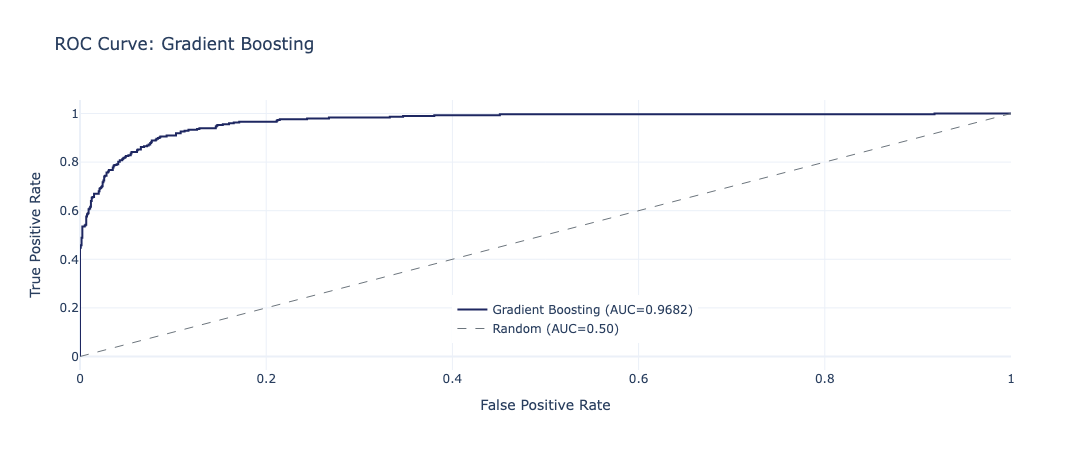

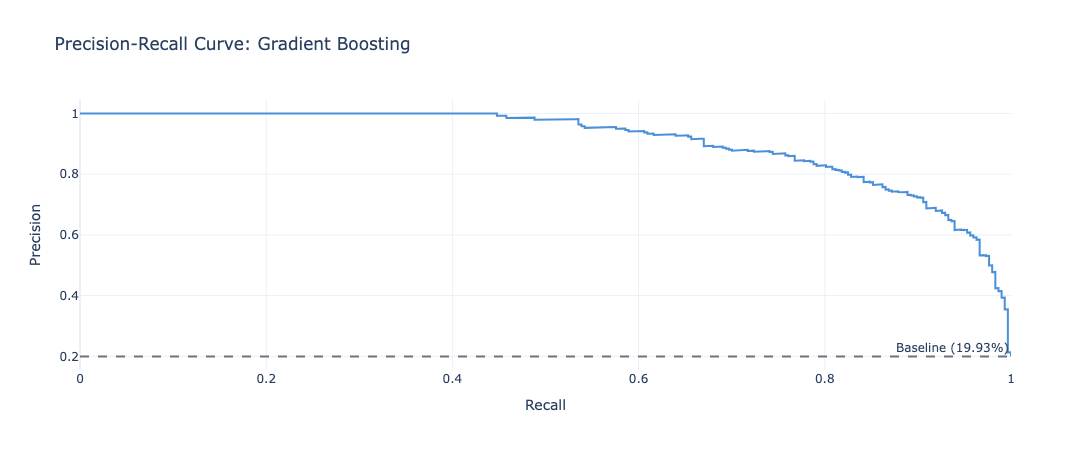

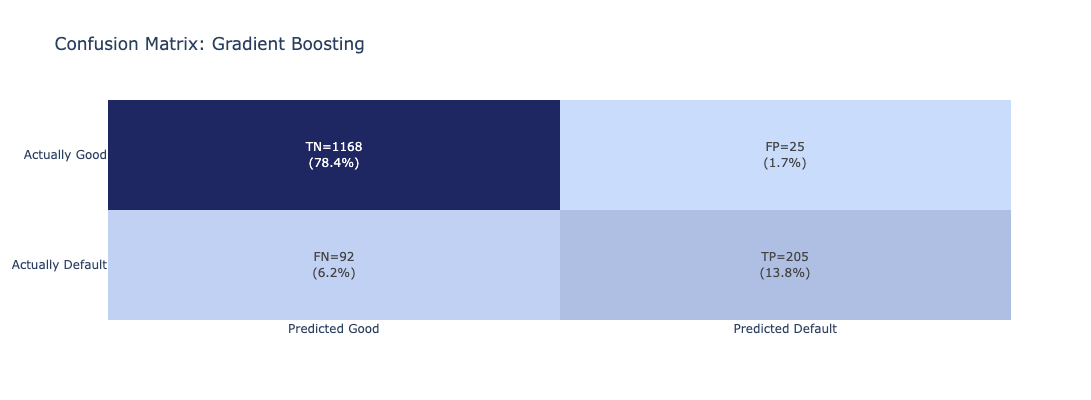

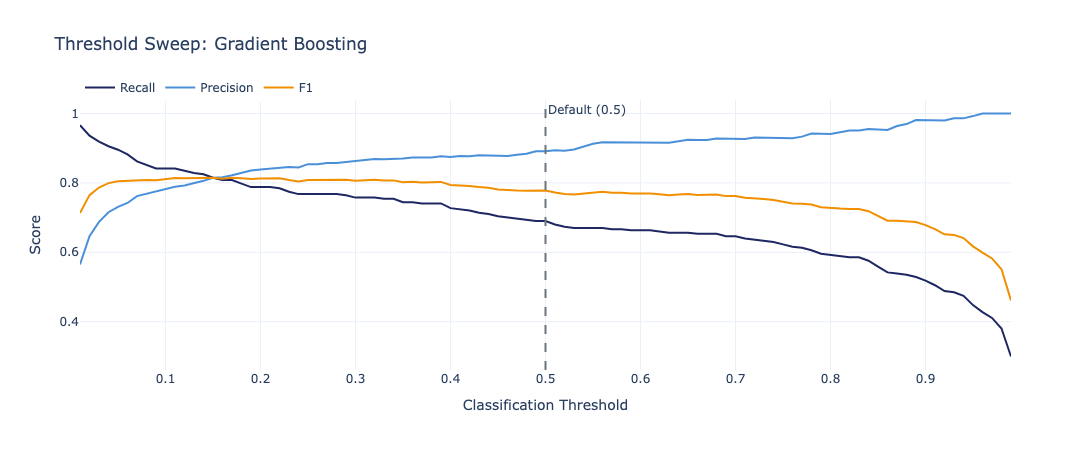

In [13]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()

---
## 13. Summary

### Where Gradient Boosting Sits on the Tradeoff Spectrum

Gradient boosting lands in the **moderate to moderate-aggressive** zone, depending on learning rate, n_estimators, and tree depth. Small learning rates push it toward moderate (more conservative); large learning rates with deep trees push toward aggressive.

### Strengths for This Problem
- **Flexible loss functions**: We use deviance loss (log loss) which is well-calibrated for probability estimates
- **Powerful predictive performance**: Often outperforms Random Forest and AdaBoost in practice
- **Feature importance is meaningful**: Gain-based importance reflects actual predictive contribution
- **Regularization options**: Learning rate, tree depth, min_samples_leaf, and subsampling all help prevent overfitting
- **Early stopping capable**: Can monitor validation loss and stop before overfitting
- **Interpretable**: Trees are still the base learner, so decisions can be inspected
- **Modern foundation**: XGBoost, LightGBM, CatBoost are all variants of gradient boosting

### Limitations for This Problem
- **Hyperparameter tuning is complex**: More knobs to tune than AdaBoost (learning_rate, max_depth, min_samples_leaf, subsample, n_estimators, etc.)
- **Slower than random forest**: Sequential training cannot be parallelized (each tree depends on prior residuals)
- **Requires careful tuning**: A poorly tuned GradientBoostingClassifier can underperform simpler models
- **Loss function matters**: Choice of loss (deviance vs squared error vs custom) significantly impacts results
- **Bias toward small learning rates**: Very small learning rates (0.001) require many estimators and long training time

### Key Takeaway
Gradient boosting is the **modern workhorse for predictive modeling**. It combines the strengths of decision trees with the power of boosting, supported by flexible regularization options. While more complex to tune than simpler models, it consistently delivers strong performance and is the foundation for state-of-the-art libraries like XGBoost. For loan default prediction, it offers an excellent balance of interpretability and predictive power.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*